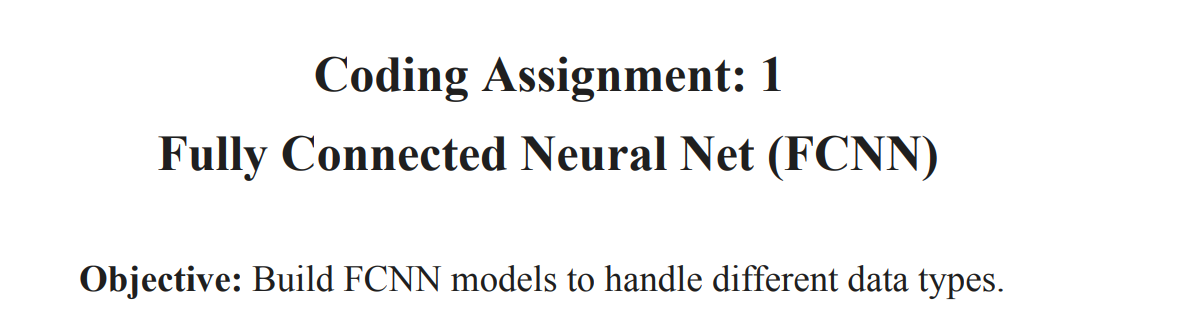

## Part 2: Vision & Feature Interpretation (Frameworks Allowed)

Goal: Bridge the gap between pixels and patterns using PyTorch.

#### Step1: Imports and Device Setup

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# MNIST Path
path = r"D:\Computer Science\IIT Mandi\Trimester 03\Datasets\MNIST"

train_file = path + r"\mnist_train.csv"
test_file = path + r"\mnist_test.csv"

Using device: cuda


#### Step 2: Load Dataset

In [3]:
train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (60000, 785)
Test shape: (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Observations
- The mnist_train.csv file contains the 60,000 training examples and labels.
- The mnist_test.csv contains 10,000 test examples and labels.
- Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

#### Step 3 – Separate Features and Labels

In [4]:
# Separate features and labels
X_train = train_df.drop("label", axis=1).values.astype(np.float32)
y_train = train_df["label"].values.astype(np.longlong)

X_test = test_df.drop("label", axis=1).values.astype(np.float32)
y_test = test_df["label"].values.astype(np.longlong)

print("Feature shape:", X_train.shape)
print("Label shape:", y_train.shape)

Feature shape: (60000, 784)
Label shape: (60000,)


#### Step 4 – Normalize Pixel Values
- MNIST pixel values are from 0–255.
- Neural networks perform better if values are scaled to 0–1.

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

#### Step 5 – Create PyTorch Dataset Class

In [6]:
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

#### Step 6 – Create DataLoaders

In [7]:
train_dataset = MNISTDataset(X_train, y_train)
test_dataset = MNISTDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

#### Step 7 – Define FCNN Model
Architecture: 784 → 256 → 128 → 10

In [8]:
class MNIST_FCNN(nn.Module):
    def __init__(self):
        super(MNIST_FCNN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        return self.model(x)

#### Step 8 – Training Function
- Loss → CrossEntropyLoss (since 10 classes)
- Optimizer → Adam
- Accuracy tracking

In [9]:
def train_mnist(model, train_loader, test_loader, epochs=15, lr=0.001):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
    
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    accuracy = correct / total
    return accuracy

#### Step 9 – Train on Standard MNIST

In [10]:
model_standard = MNIST_FCNN()

accuracy_standard = train_mnist(model_standard, train_loader, test_loader)

print("Test Accuracy (Standard MNIST):", accuracy_standard)

Epoch [1/15], Loss: 0.4419
Epoch [2/15], Loss: 0.1747
Epoch [3/15], Loss: 0.1184
Epoch [4/15], Loss: 0.0861
Epoch [5/15], Loss: 0.0655
Epoch [6/15], Loss: 0.0517
Epoch [7/15], Loss: 0.0418
Epoch [8/15], Loss: 0.0330
Epoch [9/15], Loss: 0.0265
Epoch [10/15], Loss: 0.0225
Epoch [11/15], Loss: 0.0179
Epoch [12/15], Loss: 0.0140
Epoch [13/15], Loss: 0.0100
Epoch [14/15], Loss: 0.0089
Epoch [15/15], Loss: 0.0078
Test Accuracy (Standard MNIST): 0.9794


# Question 2.1 – Weight Visualisation

### The Task: Build an FCNN using a library (PyTorch). Once trained, extract the weights of the first hidden layer.

### Reshape: Extract the 784 weights for a single neuron and reshape them into a 28x28

#### Step 10 – Extract First Layer Weights

In [11]:
# Extract first layer weights
first_layer_weights = model_standard.model[0].weight.data.cpu().numpy()

print("Weight matrix shape:", first_layer_weights.shape)

Weight matrix shape: (256, 784)


#### Observation:
- It means there are 256 neurons and 784 weights each

### Visualise: Plot this matrix as a heatmap (e.g., using matplotlib's imshow).

#### Step 11 – Visualize 10 Neurons
- Pick first 10 neurons
- Reshape 784 → 28×28
- Plot heatmaps

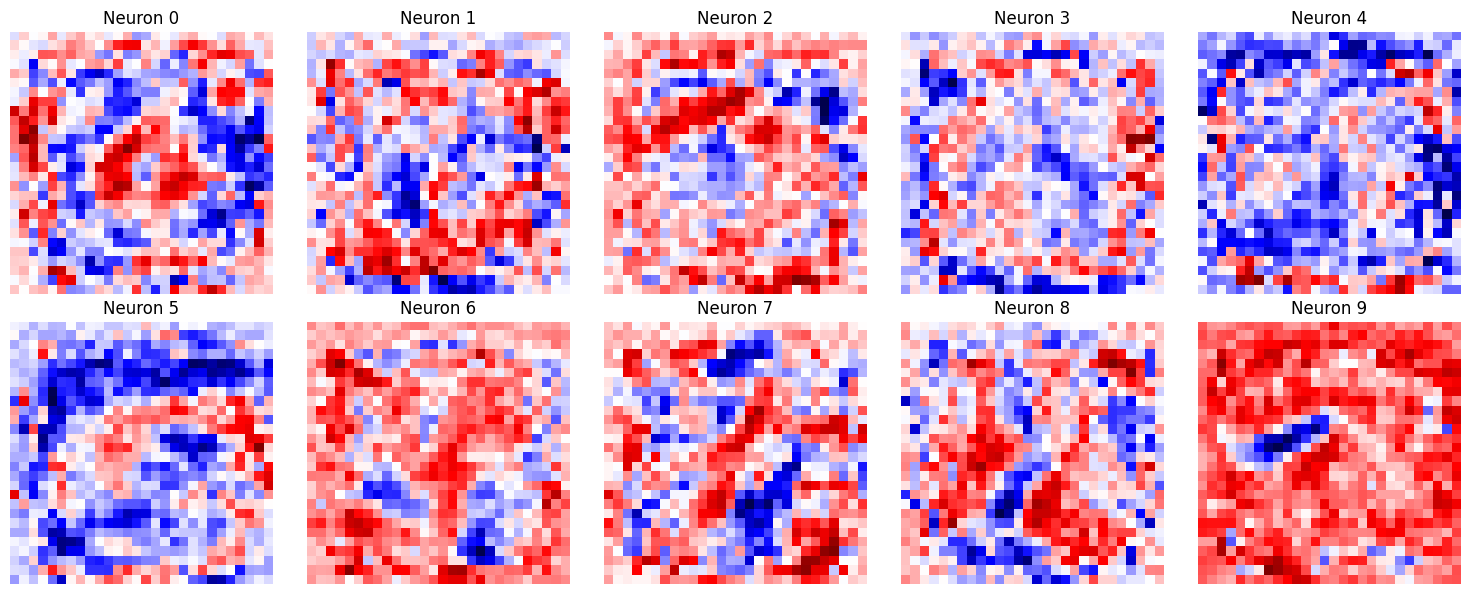

In [12]:
import matplotlib.pyplot as plt

# Select first 10 neurons
num_neurons = 10

plt.figure(figsize=(15, 6))

for i in range(num_neurons):
    weights = first_layer_weights[i]  # 784 weights
    weights_reshaped = weights.reshape(28, 28)
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(weights_reshaped, cmap='seismic')
    plt.title(f"Neuron {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Interpret: Identify the patterns. For example, does Neuron #5 have high weights (bright spots) in a circular pattern? This suggests it is "firing" when it detects the curve of a '0' or '8'.

## Interpretation – First Layer Weight Visualisation

1.  
Each neuron in the first hidden layer has 784 incoming weights, corresponding to the 28x28 pixel grid. When reshaped into image form, these weights reveal the type of patterns that each neuron is sensitive to.

2.  
Some neurons appear to highlight circular or curved structures. This suggests that those neurons may activate strongly when detecting rounded shapes such as digits '0', '6', '8', or '9'.

3.  
Other neurons show stronger intensity along vertical or diagonal regions. These neurons may be detecting stroke-like features commonly found in digits such as '1', '4', or '7'.

4.  
Certain neurons appear more noisy and less structured. This indicates that not all neurons learn highly interpretable patterns; some may contribute in more distributed or subtle ways.

5.  
The red and blue regions represent positive and negative weights. Bright regions indicate pixels that strongly influence neuron activation. This confirms that even a fully connected network learns primitive feature detectors.

6.  
Although this is not a convolutional network, the first layer still learns meaningful spatial-like patterns because the input pixels are arranged in a consistent flattened order.

# Question 2.2 – The “Flattening” / Pixel Shuffle Experiment

### The Task: Randomly shuffle the pixels of every image in the MNIST dataset (use the same shuffle pattern for all images). Train your FCNN on this "scrambled" data.

#### Step 12 – Create Fixed Pixel Shuffle

In [13]:
# Generate one fixed random permutation
np.random.seed(42)
shuffle_indices = np.random.permutation(784)

# Apply shuffle to all images
X_train_shuffled = X_train[:, shuffle_indices]
X_test_shuffled = X_test[:, shuffle_indices]

print("Shuffled shape:", X_train_shuffled.shape)

Shuffled shape: (60000, 784)


#### Step 13 – Create Shuffled Dataset

In [14]:
train_dataset_shuffled = MNISTDataset(X_train_shuffled, y_train)
test_dataset_shuffled = MNISTDataset(X_test_shuffled, y_test)

train_loader_shuffled = DataLoader(train_dataset_shuffled, batch_size=256, shuffle=True)
test_loader_shuffled = DataLoader(test_dataset_shuffled, batch_size=256)

#### Step 14 – Train New Model on Shuffled Data

In [15]:
model_shuffled = MNIST_FCNN()

accuracy_shuffled = train_mnist(model_shuffled, train_loader_shuffled, test_loader_shuffled)

print("Test Accuracy (Shuffled MNIST):", accuracy_shuffled)

Epoch [1/15], Loss: 0.4381
Epoch [2/15], Loss: 0.1728
Epoch [3/15], Loss: 0.1188
Epoch [4/15], Loss: 0.0880
Epoch [5/15], Loss: 0.0692
Epoch [6/15], Loss: 0.0542
Epoch [7/15], Loss: 0.0438
Epoch [8/15], Loss: 0.0356
Epoch [9/15], Loss: 0.0294
Epoch [10/15], Loss: 0.0239
Epoch [11/15], Loss: 0.0175
Epoch [12/15], Loss: 0.0156
Epoch [13/15], Loss: 0.0113
Epoch [14/15], Loss: 0.0104
Epoch [15/15], Loss: 0.0085
Test Accuracy (Shuffled MNIST): 0.9775


## Results – Standard vs Shuffled MNIST

1.  
The model trained on standard MNIST achieved an accuracy of 97.94%, showing strong classification performance.

2.  
After randomly shuffling the pixels of every image (using the same permutation), the model still achieved 97.75% accuracy.

3.  
The difference between the two experiments is very small (around 0.2%), which indicates that the FCNN is largely unaffected by spatial scrambling of pixels.

4.  
The training loss behavior in both cases is very similar, with smooth and stable convergence.

5.  
This suggests that the fully connected network does not rely on spatial locality of pixels, but rather on global statistical relationships between pixel values.

## Human vs Machine Reflection

1.  
If the pixels of a digit are randomly shuffled across the image, a human would struggle to recognize the digit because the spatial structure is destroyed.

2.  
However, the FCNN still performs almost equally well because it treats the input as a flat vector of numbers, not as a 2D image.

3.  
The network does not understand shapes or spatial continuity. It only learns weighted combinations of pixel intensities.

4.  
As long as the shuffle pattern is consistent across all images, the statistical mapping between pixel positions and labels remains learnable for the network.

## Architectural Insight

1.  
A Fully Connected Neural Network is blind to spatial structure because it does not preserve neighborhood relationships between pixels.

2.  
Each input pixel is treated independently and connected to every neuron in the next layer.

3.  
Unlike Convolutional Neural Networks (CNNs), FCNNs do not use local receptive fields or weight sharing.

4.  
This experiment demonstrates why FCNNs are not ideal for complex image tasks, even though they can still achieve high accuracy on simple datasets like MNIST.

5.  
CNNs are more suitable for vision tasks because they explicitly model spatial patterns and translation invariance.